In [1]:
import re
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [2]:
trained_model_indicator_index = "sing_01"

notebook_path = os.getcwd() + "/"
loss_profile_path = notebook_path + "loss_evolution/"
panel_c_image_path = notebook_path + "panel_c/"

In [3]:
directory = Path(loss_profile_path)

In [4]:
epochs = []
train_geo_losses = []
valid_geo_losses = []

for p in directory.glob("*.out"):
    file_string = str(p)
    with open(p, 'r') as file:
        for line_number, line in enumerate(file, start=1):
            # print(line.strip())  # .strip() removes newline characters
            if re.search(r'\btra_loss=\b', line, re.IGNORECASE):
                # print(f"Line {line_number}: Found 'train' -> {line.strip()}")
                result = re.split(r"[ep ;:;=;,;\n]", line)
                # print("train result", result)
                train_geo_losses.append( float(result[6]))
                epochs.append(int(result[3]))            
                # print("train - geodesic loss:",  float(result[6]))
                
            if re.search(r'\bval_loss=\b', line, re.IGNORECASE):
                # print(f"Line {line_number}: Found 'valid' -> {line.strip()}")
                result = re.split(r"[=;,;\n]", line)
                # print("valid result", result)
                valid_geo_losses.append( float(result[1]))            
                # print("valid - geodesic loss:",  float(result[1]))

# Zip the lists together
combined = list(zip(epochs, train_geo_losses, valid_geo_losses))

# Sort by epoch (first element of each tuple)
combined.sort(key=lambda x: x[0])

# Unzip back into separate lists
epochs, train_geo_losses, valid_geo_losses = map(list, zip(*combined))


In [5]:
np.max(train_geo_losses)

np.float64(0.5657408)

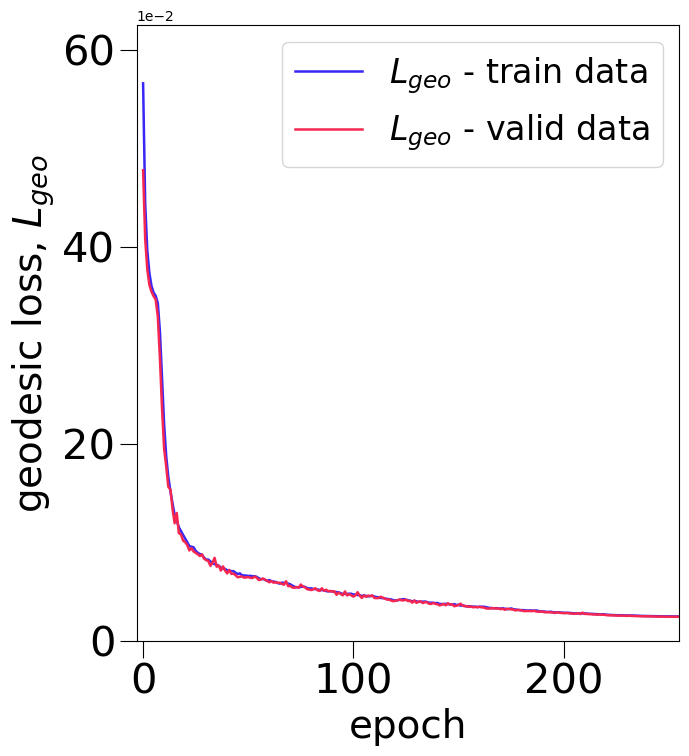

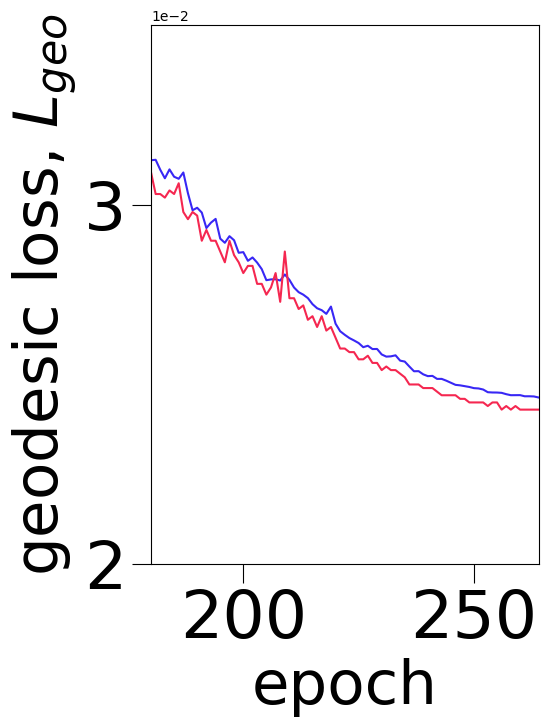

In [6]:
# OVERALL Loss evolution profile.
fig, ax = plt.subplots(1, 1, figsize=(7, 8))
ax.plot(epochs, train_geo_losses, color = '#3827F5', linewidth = 1.8, label=r'$L_{geo}$ - train data')
ax.plot(epochs, valid_geo_losses, color = '#F52750', linewidth = 1.8, label=r'$L_{geo}$ - valid data')
ax.set_xlabel(r"epoch", fontsize = 28)
ax.set_ylabel(r"geodesic loss, $L_{geo}$", fontsize = 28)
ax.legend(fontsize = 24)
ax.set_xlim([-3,255])
ax.set_ylim([0.0,0.625])
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
formatter = ScalarFormatter(useOffset=False) # useOffset=False prevents an additional offset term
formatter.set_powerlimits((-2, -2)) # Force scientific notation for numbers within 10^-3 to 10^-3
formatter.set_scientific(True) # Ensure scientific notation is used
ax.yaxis.set_major_formatter(formatter)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=30)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=30)
plt.savefig(panel_c_image_path + trained_model_indicator_index + "_" + "evolution_of_geodesic_losses.pdf", bbox_inches='tight')
plt.show()

# Zoomed in loss evolution profile.
fig, ax = plt.subplots(1, 1, figsize=(5, 7))
ax.plot(epochs, train_geo_losses, color = '#3827F5', label=r'$L_{geo}$ - train data')
ax.plot(epochs, valid_geo_losses, color = '#F52750', label=r'$L_{geo}$ - valid data')
ax.set_xlabel(r"epoch", fontsize = 44)
ax.set_ylabel(r"geodesic loss, $L_{geo}$", fontsize = 44)
ax.set_xlim([180,264])
ax.set_ylim([0.02,0.035])
ax.set_yticks([0.02, 0.03])
formatter = ScalarFormatter(useOffset=False) # useOffset=False prevents an additional offset term
formatter.set_powerlimits((-2, -2)) # Force scientific notation for numbers within 10^-3 to 10^-3
formatter.set_scientific(True) # Ensure scientific notation is used
ax.yaxis.set_major_formatter(formatter)
ax.tick_params(axis='x', direction='out', length=14, width=0.8, color='k', labelsize=48)
ax.tick_params(axis='y', direction='out', length=14, width=0.8, color='k', labelsize=48)
plt.savefig(panel_c_image_path + trained_model_indicator_index + "_" + "evolution_of_geodesic_losses_zoomed.pdf", bbox_inches='tight')
plt.show()